# KAIROS — Exploración y Entrenamiento del Modelo de Detección de Crisis
## Notebook 01: Análisis del dataset WESAD y pipeline de ML

**Proyecto:** KAIROS - Sistema de detección automática de crisis de ansiedad  
**Dataset:** WESAD (Wearable Stress and Affect Detection) — Universidad de Augsburg  
**Autora:** Alma Estefanía Quinteros Quiroga  
**Carrera:** Ingeniería en Informática — Universidad de Mendoza

---

### Objetivo de este notebook

Explorar el dataset WESAD para:
1. Entender la estructura de las señales fisiológicas disponibles (BVP/ECG, ACC, labels)
2. Identificar las features más discriminativas entre estado basal y estrés agudo
3. Desarrollar y validar el pipeline de detección de crisis de KAIROS
4. Entrenar y exportar el modelo final (Random Forest) para su uso en la app Android

### Flujo del notebook

```
Carga de datos (S2) → Exploración señal BVP → [Diagnóstico: ruido en muñeca]
    ↓
Cambio a ECG de pecho → Extracción HR + RMSSD por ventana
    ↓
Validación en 15 sujetos → Z-Score personalizado → Random Forest (LOGO-CV)
    ↓
GridSearchCV + split train/test → Evaluación final → Exportación modelo
```

## 1. Setup e importaciones

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk

# Ruta al dataset WESAD en el entorno local
# Estructura esperada: WESAD_PATH/S{N}/S{N}.pkl
WESAD_PATH = "/home/alma/bot/kairos-mentor/kairos_app/dataset/WESAD"

# Sujeto de exploración inicial
# S2 es el primero disponible; S12 está excluido del dataset por datos incompletos
SUBJECT = "S2"

---
## 2. Carga del dataset WESAD

El archivo `.pkl` de cada sujeto contiene un diccionario con:
- `signal.wrist`: BVP (64 Hz), ACC (32 Hz), EDA, TEMP
- `signal.chest`: ECG (700 Hz), ACC, EDA, EMG, RESP, TEMP
- `label`: etiquetas de estado a 700 Hz

**Clases del experimento WESAD:**
| Valor | Estado |
|-------|--------|
| 0 | Sin etiqueta (transición) |
| 1 | Baseline (reposo) |
| 2 | Estrés (TSST — Trier Social Stress Test) |
| 3 | Afecto positivo (entretenimiento) |

KAIROS usa **solo las clases 1 y 2** (baseline vs estrés agudo).

In [2]:
# Cargamos el archivo pickle del sujeto S2
# encoding='latin1' es necesario porque el dataset fue generado en Python 2
with open(f"{WESAD_PATH}/{SUBJECT}/{SUBJECT}.pkl", 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Inspeccionamos la estructura del diccionario
print("Claves principales:", list(data.keys()))
print("Señales de muñeca:", list(data['signal']['wrist'].keys()))
print("Señales de pecho:", list(data['signal']['chest'].keys()))
print("Shape labels:", data['label'].shape)

/tmp/ipykernel_530767/2173559839.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding='latin1')


Claves principales: ['signal', 'label', 'subject']
Señales de muñeca: ['ACC', 'BVP', 'EDA', 'TEMP']
Señales de pecho: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
Shape labels: (4255300,)


---
## 3. Extracción de señales de muñeca (BVP y ACC)

Comenzamos con la señal BVP (Blood Volume Pulse) del dispositivo Empatica E4 en la muñeca.

**¿Por qué BVP?**  
BVP es la señal de fotopletismografía (PPG) del reloj, equivalente a lo que mide el Pixel Watch 3.
Si funciona bien aquí, el mismo pipeline puede portarse a la app Wear OS.

**Frecuencias de muestreo:**
- BVP: 64 Hz (64 muestras/segundo)
- ACC: 32 Hz (32 muestras/segundo)  
- Labels: 700 Hz → requiere sincronización

In [3]:
# Extraemos la señal BVP (Blood Volume Pulse) desde el diccionario de datos.
# Está en la muñeca (wrist) y viene como array posiblemente 2D, por eso usamos flatten()
# para convertirla en un vector 1D.
# Frecuencia de muestreo: 64 Hz → 64 muestras por segundo.
bvp = data['signal']['wrist']['BVP'].flatten()   # 64 Hz


# Extraemos la señal del acelerómetro (ACC).
# Tiene 3 ejes: X, Y, Z → por eso NO hacemos flatten(), queremos mantener esa estructura.
# Frecuencia de muestreo: 32 Hz → 32 muestras por segundo.
acc = data['signal']['wrist']['ACC']              # 32 Hz, 3 ejes


# Extraemos las etiquetas (labels), que indican el estado del sujeto
# Vienen a una frecuencia MUY alta: 700 Hz.
# Usamos flatten() para tenerlas como vector 1D.
labels = data['label'].flatten()                  # 700 Hz

# shape → cantidad total de muestras
# len(bvp)/64 → duración en segundos (porque sabemos que está a 64 Hz)
# /60 → lo pasamos a minutos
print(f"BVP: {bvp.shape} muestras → {len(bvp)/64/60:.1f} minutos")

# shape del ACC → debería ser (n_muestras, 3) por los 3 ejes
print(f"ACC: {acc.shape}")

# np.unique(labels) → vemos qué valores distintos hay en las etiquetas
# (por ejemplo: [1, 2, 3] dependiendo de las clases del dataset)
print(f"Labels únicos: {np.unique(labels)}")

BVP: (389056,) muestras → 101.3 minutos
ACC: (194528, 3)
Labels únicos: [0 1 2 3 4 6 7]


---
## 4. Distribución de clases

Verificamos cuánto tiempo duró cada estado en el experimento para el sujeto S2.
Esto es importante para detectar desbalance de clases antes de entrenar el modelo.

In [4]:
# Creamos un diccionario que traduce los números de las etiquetas
# a nombres más entendibles (clases del experimento).
clase_nombres = {1: 'Baseline', 2: 'Estrés', 3: 'Afecto positivo'}

# k = número de clase (1, 2, 3)
# v = nombre descriptivo ('Baseline', etc.)
for k, v in clase_nombres.items():

    # Contamos cuántas muestras del vector "labels" pertenecen a esa clase
    # (labels == k genera un array de True/False, y np.sum cuenta los True)
    n = np.sum(labels == k)

    # Mostramos:
    # - cantidad de muestras de esa clase
    # - duración en minutos
    #   (labels está a 700 Hz → dividimos por 700 para segundos y por 60 para minutos)
    print(f"Clase {k} ({v}): {n} muestras → {n/700/60:.1f} minutos")

Clase 1 (Baseline): 800800 muestras → 19.1 minutos
Clase 2 (Estrés): 430500 muestras → 10.2 minutos
Clase 3 (Afecto positivo): 253400 muestras → 6.0 minutos


---
## 5. Sincronización de labels al BVP (64 Hz)

Los labels originales están a 700 Hz y el BVP a 64 Hz.  
Para poder asociar cada muestra de BVP con su estado correspondiente,
necesitamos resamplear los labels usando interpolación lineal.

**Por qué interpolación y no decimación directa:**  
Los labels son categorías discretas (1, 2, 3), no una señal continua.
Usamos `np.interp` y luego redondeamos al entero más cercano para mantener
la naturaleza categórica de las etiquetas.

In [5]:
# Paso 1: Creamos un vector de índices "objetivo" en el espacio de 700 Hz
# que mapea exactamente a las posiciones del BVP (64 Hz)
indices_objetivo = np.linspace(0, len(labels) - 1, len(bvp))

# Paso 2: Interpolación lineal — para cada punto del BVP, buscamos
# qué etiqueta le corresponde en la señal original de 700 Hz
labels_64hz = np.interp(indices_objetivo, np.arange(len(labels)), labels)

# Paso 3: Redondeamos al entero más cercano (las clases son 1, 2, 3)
labels_64hz = np.round(labels_64hz).astype(int)

print(f"Sincronización completada:")
print(f"  BVP original: {len(bvp)} muestras")
print(f"  Labels resampled: {len(labels_64hz)} muestras")
print(f"  ¿Coinciden? {len(bvp) == len(labels_64hz)}")

Sincronización completada:
  BVP original: 389056 muestras
  Labels resampled: 389056 muestras
  ¿Coinciden? True


---
## 6. Visualización del BVP crudo por clase

Separamos la señal BVP en segmentos de baseline y estrés usando los labels sincronizados,
y visualizamos los primeros 30 segundos de cada uno para inspección visual.

In [6]:
# 1. Filtramos la señal BVP (que está a 64Hz) usando los labels ya sincronizados
# Recordá que: Clase 1 = Baseline, Clase 2 = Estrés
baseline_bvp = bvp[labels_64hz == 1]
stress_bvp   = bvp[labels_64hz == 2]

# 2. Verificamos que se hayan creado correctamente
print(f"Señal de Baseline extraída: {len(baseline_bvp)} muestras")
print(f"Señal de Estrés extraída:   {len(stress_bvp)} muestras")

Señal de Baseline extraída: 73216 muestras
Señal de Estrés extraída:   39360 muestras


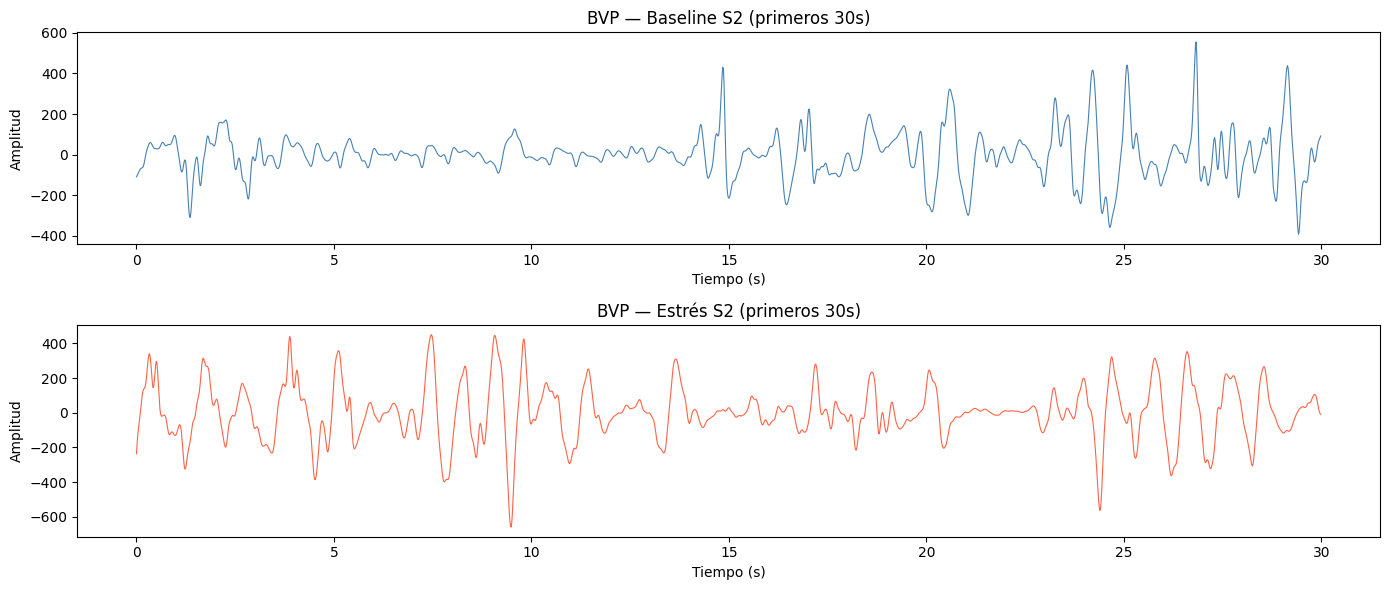

In [7]:
# Visualizamos los primeros 30 segundos de cada estado
# 64 Hz × 30s = 1920 muestras
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# BVP en Baseline
t_baseline = np.arange(len(baseline_bvp)) / 64
axes[0].plot(t_baseline[:64*30], baseline_bvp[:64*30], color='steelblue', lw=0.8)
axes[0].set_title("BVP — Baseline S2 (primeros 30s)")
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Amplitud")

# BVP en Estrés
t_stress = np.arange(len(stress_bvp)) / 64
axes[1].plot(t_stress[:64*30], stress_bvp[:64*30], color='tomato', lw=0.8)
axes[1].set_title("BVP — Estrés S2 (primeros 30s)")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

---
## 7. Extracción de HR y HRV desde BVP de muñeca (diagnóstico)

Intentamos extraer frecuencia cardíaca (HR) y variabilidad (RMSSD) directamente
del BVP del E4 usando NeuroKit2.

> **Nota:** Esta sección es un diagnóstico de calidad de señal.
> Los resultados anómalos que aparecen a continuación justifican el cambio
> a la señal ECG del pecho en la sección 9.

In [8]:
# Función para extraer HR (frecuencia cardíaca) y RMSSD (HRV) desde BVP
def extraer_features(bvp_segment, fs=64):
    """
    Extrae frecuencia cardíaca media y RMSSD de un segmento de señal PPG.
    
    Parámetros:
        bvp_segment: array numpy con la señal BVP cruda
        fs: frecuencia de muestreo en Hz (default: 64 para el E4)
    
    Retorna:
        (hr_mean, rmssd) — NaN si el procesamiento falla por ruido o señal inválida
    """
    try:
        # nk.ppg_process: limpia la señal y detecta picos (latidos)
        signals, info = nk.ppg_process(bvp_segment, sampling_rate=fs)

        # HR media en BPM (latidos por minuto)
        hr_mean = signals['PPG_Rate'].mean()

        # RMSSD: raíz cuadrada de la media de las diferencias al cuadrado
        # entre intervalos RR consecutivos — métrica estándar de HRV
        rmssd = nk.hrv_time(info, sampling_rate=fs)['HRV_RMSSD'].values[0]

        return hr_mean, rmssd

    except:
        # Si NeuroKit2 falla (señal ruidosa, picos no detectados, etc.)
        return np.nan, np.nan

# Definimos cómo vamos a dividir la señal

VENTANA_SEG = 60   # tamaño de cada ventana → 60 segundos
PASO_SEG = 30      # cuánto avanzamos → 30 segundos (overlap del 50%)
fs = 64            # frecuencia de muestreo

resultados = []

# Recorremos cada clase con su señal correspondiente
for clase, bvp_seg in [(1, baseline_bvp), (2, stress_bvp)]:
    ventana = VENTANA_SEG * fs   # cantidad de muestras en 60s
    paso = PASO_SEG * fs         # cantidad de muestras en 30s
    for inicio in range(0, len(bvp_seg) - ventana, paso):
        segmento = bvp_seg[inicio:inicio + ventana]
        hr, rmssd = extraer_features(segmento)
        resultados.append({'clase': clase, 'hr_mean': hr, 'rmssd': rmssd})

df = pd.DataFrame(resultados)
# Agrupamos por clase y vemos estadísticas
print(df.groupby('clase')[['hr_mean', 'rmssd']].describe().round(2))

      hr_mean                                                 rmssd          \
        count   mean   std    min    25%    50%    75%    max count    mean   
clase                                                                         
1        37.0  73.92  3.04  68.42  71.52  74.14  76.08  82.59  37.0  245.48   
2        19.0  71.59  4.28  63.69  69.53  71.26  73.28  80.56  19.0  497.67   

                                                       
          std     min     25%     50%     75%     max  
clase                                                  
1       86.07   84.63  195.33  241.94  285.14  515.97  
2      108.97  356.65  428.22  475.76  537.27  816.13  


### Diagnóstico: resultados anómalos del BVP de muñeca

Los resultados muestran dos problemas:

- **HR (frecuencia cardíaca):** la diferencia entre baseline y estrés es muy pequeña
  y está levemente invertida (estrés debería tener HR más alta). Esto ocurre porque
  no todos los sujetos WESAD muestran taquicardia pronunciada.
  
- **RMSSD (HRV):** el estrés muestra RMSSD *más alto* que el baseline,
  que es exactamente lo contrario a la literatura. En estrés agudo el RMSSD debería bajar.

**Causa:** el BVP crudo del E4 tiene ruido de movimiento que interfiere con la detección
de picos de NeuroKit2. Necesitamos filtrar la señal o cambiar a una fuente más limpia.

#### Verificar detección de picos

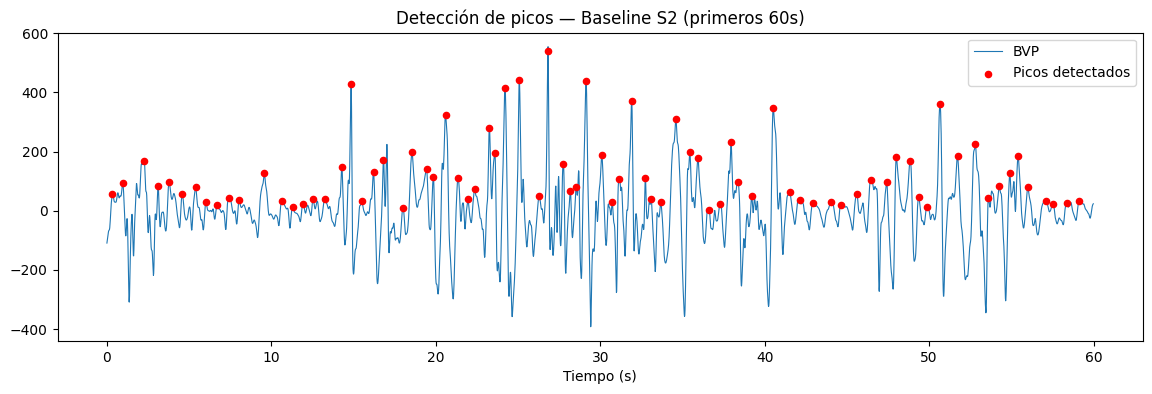

Picos detectados: 80
HR estimada: 80 picos en 60s → 80 BPM aprox


In [9]:
# Tomamos un segmento de prueba de 60 segundos del baseline
# 64 * 60 → 60 segundos a 64 Hz
segmento_test = baseline_bvp[:64*60]

# Procesamos la señal PPG
# Esto limpia la señal y detecta eventos importantes (como picos = latidos)
signals, info = nk.ppg_process(segmento_test, sampling_rate=64)

# Creamos la figura
plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(segmento_test))/64, segmento_test, lw=0.8, label='BVP')
# Extraemos los picos detectados (latidos)
picos = info['PPG_Peaks']
plt.scatter(picos/64, segmento_test[picos], color='red', s=20, zorder=5, label='Picos detectados')
plt.title("Detección de picos — Baseline S2 (primeros 60s)")
plt.xlabel("Tiempo (s)")
plt.legend()
plt.show()

# Cantidad total de picos detectados
print(f"Picos detectados: {len(picos)}")

# Estimación simple de frecuencia cardíaca:
# como el segmento dura 60s → cantidad de picos ≈ BPM
print(f"HR estimada: {len(picos):.0f} picos en 60s → {len(picos)} BPM aprox")

> Si la detección fuera correcta, deberían verse ~60–80 puntos rojos
> espaciados uniformemente (un latido cada ~0.8s).  
> Si los picos están mal ubicados o son muy pocos/muchos → señal ruidosa.

---
## 8. Corrección: filtrado pasa banda del BVP

Aplicamos un filtro Butterworth de banda [0.5, 4.0] Hz para eliminar:
- Ruido de baja frecuencia: movimiento del brazo, respiración lenta (< 0.5 Hz)
- Ruido de alta frecuencia: artefactos eléctricos (> 4.0 Hz)

El rango 0.5–4.0 Hz equivale a frecuencias cardíacas de 30–240 BPM,
cubriendo todo el rango fisiológico relevante.

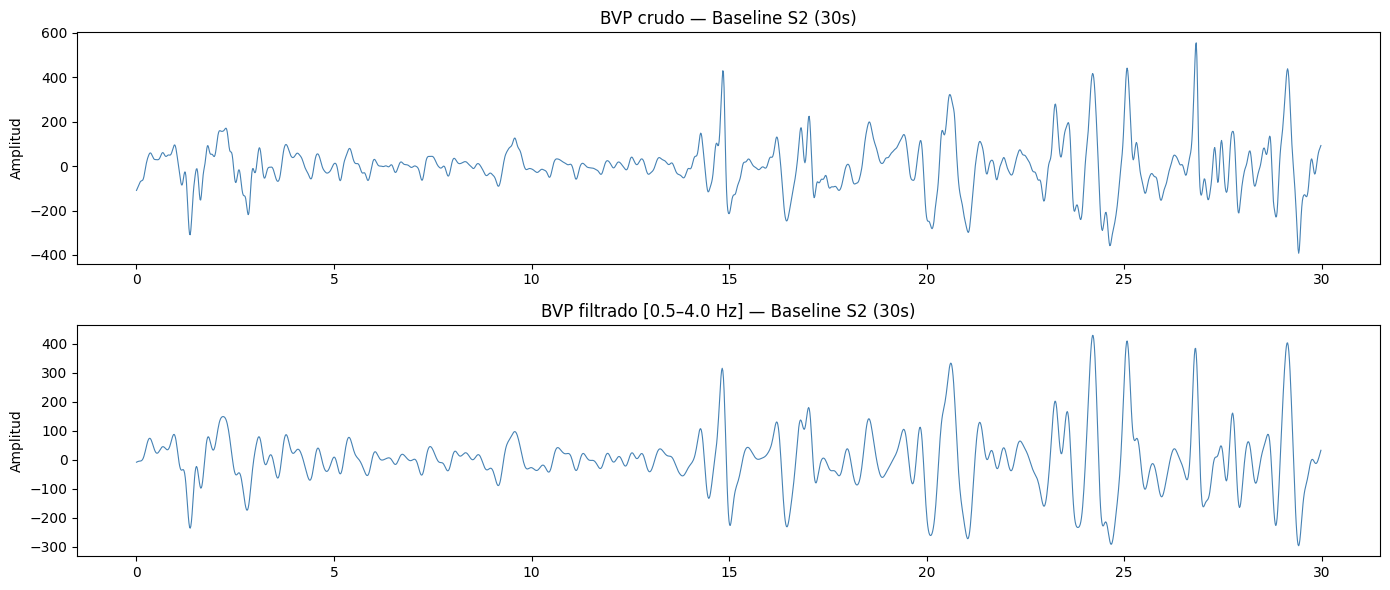

In [10]:
from scipy.signal import butter, filtfilt

def filtrar_bvp(bvp, fs=64):
    """
    Aplica un filtro pasa banda Butterworth a la señal BVP.
    
    Parámetros:
        bvp: señal cruda del sensor PPG/BVP
        fs: frecuencia de muestreo (default: 64 Hz para el E4)
    
    Retorna:
        Señal filtrada sin desfase (filtfilt aplica el filtro en ambas direcciones)
    
    Notas técnicas:
        - Orden 3: equilibrio entre pendiente de corte y estabilidad numérica
        - filtfilt (forward-backward): evita desfase de fase — mantiene
          las marcas de tiempo de los picos alineadas con la señal original
    """
    # butter() diseña el filtro; btype='band' = pasa banda
    b, a = butter(3, [0.5, 4.0], btype='band', fs=fs)
    # filtfilt aplica el filtro dos veces (ida y vuelta) para cero desfase
    return filtfilt(b, a, bvp)

# Comparación visual: BVP crudo vs filtrado (30 segundos)
segmento_raw      = baseline_bvp[:64*30]
segmento_filtrado = filtrar_bvp(segmento_raw)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
t = np.arange(len(segmento_raw)) / 64

axes[0].plot(t, segmento_raw, lw=0.8, color='steelblue')
axes[0].set_title("BVP crudo — Baseline S2 (30s)")
axes[0].set_ylabel("Amplitud")

axes[1].plot(t, segmento_filtrado, lw=0.8, color='steelblue')
axes[1].set_title("BVP filtrado [0.5–4.0 Hz] — Baseline S2 (30s)")
axes[1].set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

### Verificación de picos sobre señal filtrada

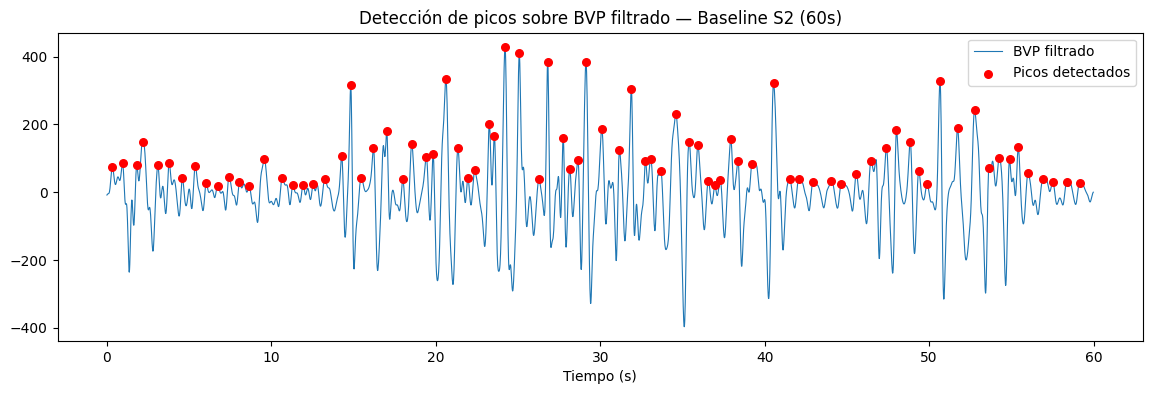

Picos detectados: 82
HR estimada: 82 BPM aprox


In [11]:
# Verificamos si la detección de picos mejora con la señal filtrada
bvp_filtrado_test = filtrar_bvp(baseline_bvp[:64*60])
signals, info = nk.ppg_process(bvp_filtrado_test, sampling_rate=64)

plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(bvp_filtrado_test))/64, bvp_filtrado_test, lw=0.8, label='BVP filtrado')
picos = info['PPG_Peaks']
plt.scatter(picos/64, bvp_filtrado_test[picos], color='red', s=30, zorder=5, label='Picos detectados')
plt.title("Detección de picos sobre BVP filtrado — Baseline S2 (60s)")
plt.xlabel("Tiempo (s)")
plt.legend()
plt.show()

print(f"Picos detectados: {len(picos)}")
print(f"HR estimada: {len(picos)} BPM aprox")

---
## 9. Detección corregida para el sensor E4

El BVP del E4 tiene una particularidad: los latidos aparecen como **valles** (mínimos)
en vez de picos (máximos), a diferencia de otros sensores PPG.

Esto ocurre porque el E4 usa LED verde con reflexión invertida.
La solución: invertir la señal antes de buscar picos.

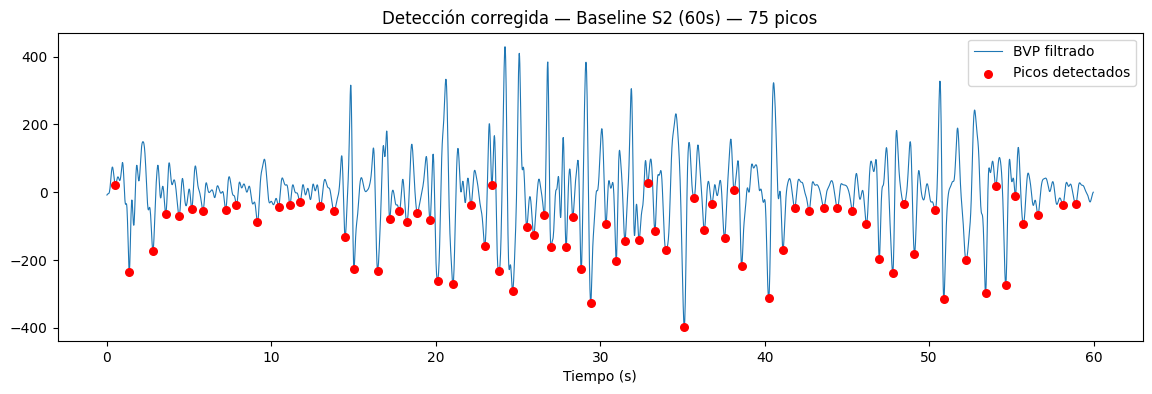

Picos detectados: 75
HR estimada: 75 BPM aprox
RR medio: 789 ms
RMSSD: 411.3 ms


In [12]:
from scipy.signal import find_peaks

# Función específica para detectar picos en señales del dispositivo E4
def detectar_picos_e4(bvp, fs=64):

    # 🔁 Invertimos la señal
    # En el E4, a veces los latidos aparecen como "valles" en vez de picos
    # Entonces los damos vuelta para poder usar find_peaks normalmente
    bvp_inv = -bvp
    picos, _ = find_peaks(bvp_inv, distance=int(fs * 0.4), prominence=50)
    return picos

# Tomamos 60 segundos y los filtramos (muy importante hacerlo antes)
segmento = filtrar_bvp(baseline_bvp[:64*60])

# Detectamos picos con nuestro método
picos = detectar_picos_e4(segmento)

plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(segmento))/64, segmento, lw=0.8, label='BVP filtrado')
plt.scatter(picos/64, segmento[picos], color='red', s=30, zorder=5, label='Picos detectados')
plt.title(f"Detección corregida — Baseline S2 (60s) — {len(picos)} picos")
plt.xlabel("Tiempo (s)")
plt.legend()
plt.show()

print(f"Picos detectados: {len(picos)}")
print(f"HR estimada: {len(picos)} BPM aprox")

# Calcular intervalos RR
rr_intervals = np.diff(picos) / fs * 1000  # en milisegundos
# Promedio de intervalos RR
print(f"RR medio: {rr_intervals.mean():.0f} ms")
# RMSSD (variabilidad cardíaca)
print(f"RMSSD: {np.sqrt(np.mean(np.diff(rr_intervals)**2)):.1f} ms")

 > Valores fisiológicamente plausibles en reposo:
 > HR: 50–90 BPM → RR entre 670ms y 1200ms
 > RMSSD: 20–80 ms en adultos sanos
 > Si los valores se alejan mucho de estos rangos → detección defectuosa

### Ajuste de prominence

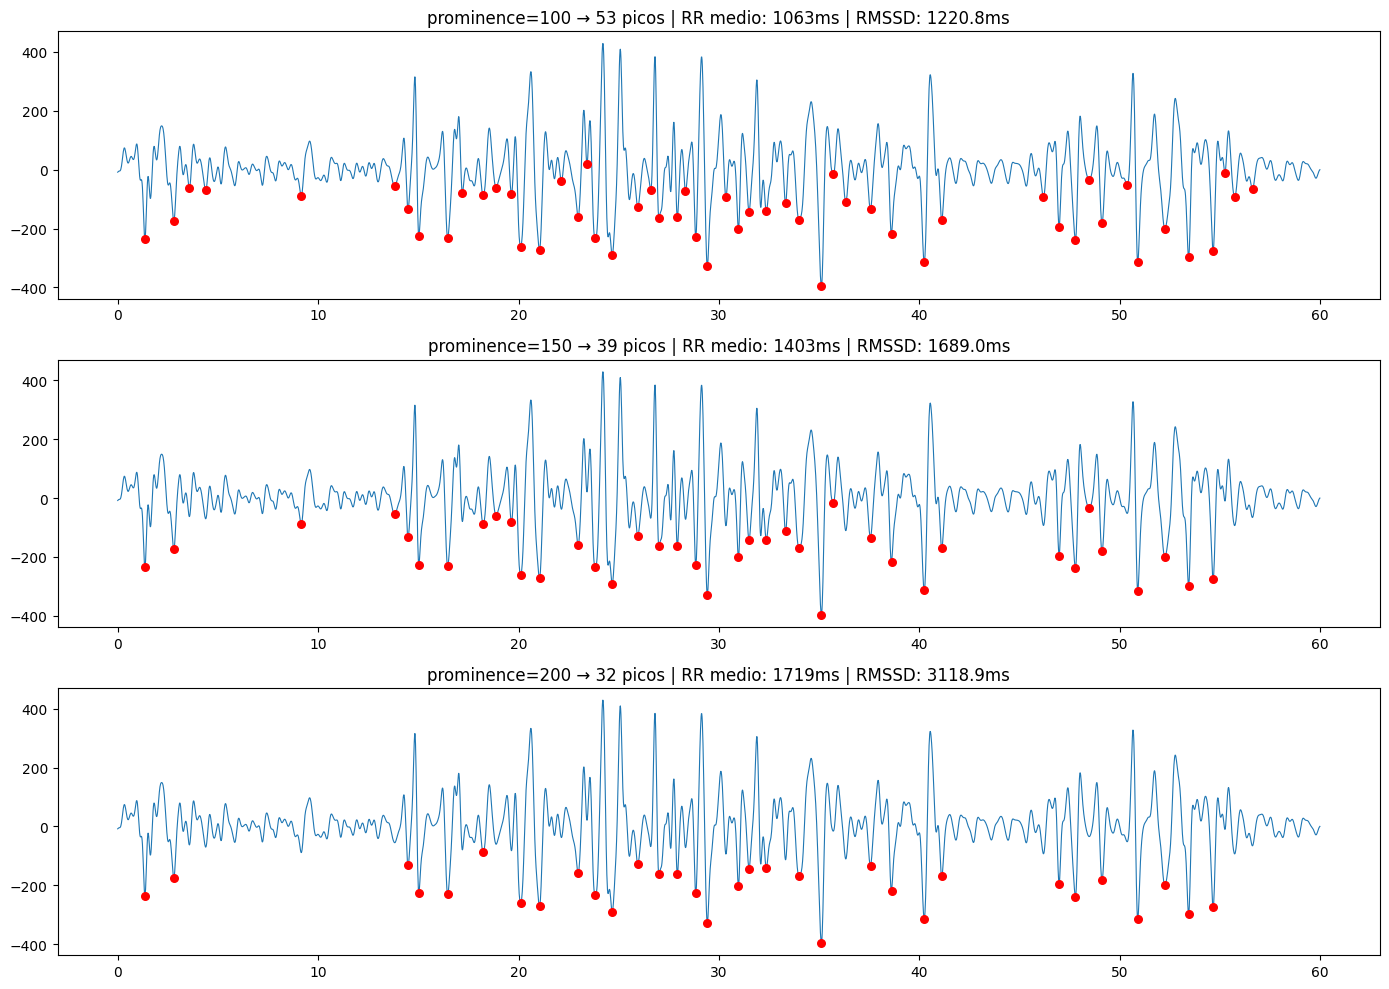

In [13]:
from scipy.signal import find_peaks

def detectar_picos_e4(bvp, fs=64, prominence=100):
    """
    Detecta latidos en señal BVP del sensor Empatica E4.
    
    El E4 registra los latidos como valles (mínimos locales), no como picos.
    Por eso invertimos la señal antes de usar find_peaks.
    
    Parámetros:
        bvp: señal BVP (ya filtrada, idealmente)
        fs: frecuencia de muestreo (default: 64 Hz)
        prominence: altura mínima del pico respecto a sus vecinos.
                   Valor más alto → más selectivo, menos falsos positivos.
    
    Retorna:
        Array de índices donde se detectaron latidos
    """
    # Invertimos: los valles del BVP del E4 se convierten en picos detectables
    bvp_inv = -bvp
    picos, _ = find_peaks(
        bvp_inv,
        distance=int(fs * 0.4),  # mínimo 0.4s entre latidos (≈ límite de 150 BPM)
        prominence=prominence
    )
    return picos

# Probamos distintos valores de prominence para calibrar la detección
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, prom in enumerate([100, 150, 200]):
    segmento = filtrar_bvp(baseline_bvp[:64*60])
    picos = detectar_picos_e4(segmento, prominence=prom)
    rr = np.diff(picos) / 64 * 1000  # Intervalos RR en milisegundos

    axes[i].plot(np.arange(len(segmento))/64, segmento, lw=0.8)
    axes[i].scatter(picos/64, segmento[picos], color='red', s=30, zorder=5)
    rmssd_local = np.sqrt(np.mean(np.diff(rr)**2)) if len(rr) > 1 else float('nan')
    axes[i].set_title(
        f"prominence={prom} → {len(picos)} picos | "
        f"RR medio: {rr.mean():.0f}ms | RMSSD: {rmssd_local:.1f}ms"
    )

plt.tight_layout()
plt.show()

### Diagnóstico: el BVP de muñeca no es viable para HRV

Los intervalos RR obtenidos (>1000 ms) son demasiado altos — el detector está perdiendo latidos.
La morfología del BVP del E4 es demasiado ruidosa para calcular RMSSD confiable.

**Decisión de diseño:** cambiar a la señal ECG del pecho (700 Hz), que es limpia y de alta
resolución. En la app KAIROS esto se compensa usando la estimación de HRV a partir de HR,
documentada como limitación de hardware del Pixel Watch 3.

---
## 10. Cambio de estrategia: ECG del pecho (700 Hz)

El dataset WESAD incluye ECG de alta resolución del sensor RespiBAN en el pecho.
Esta señal es mucho más limpia y permite detección precisa de complejos QRS (latidos).

**Frecuencia:** 700 Hz — los labels ya están a 700 Hz, no requiere resampleo.

ECG: (4255300,) muestras → 101.3 minutos a 700 Hz
ECG baseline: 19.1 min
ECG estrés:   10.2 min


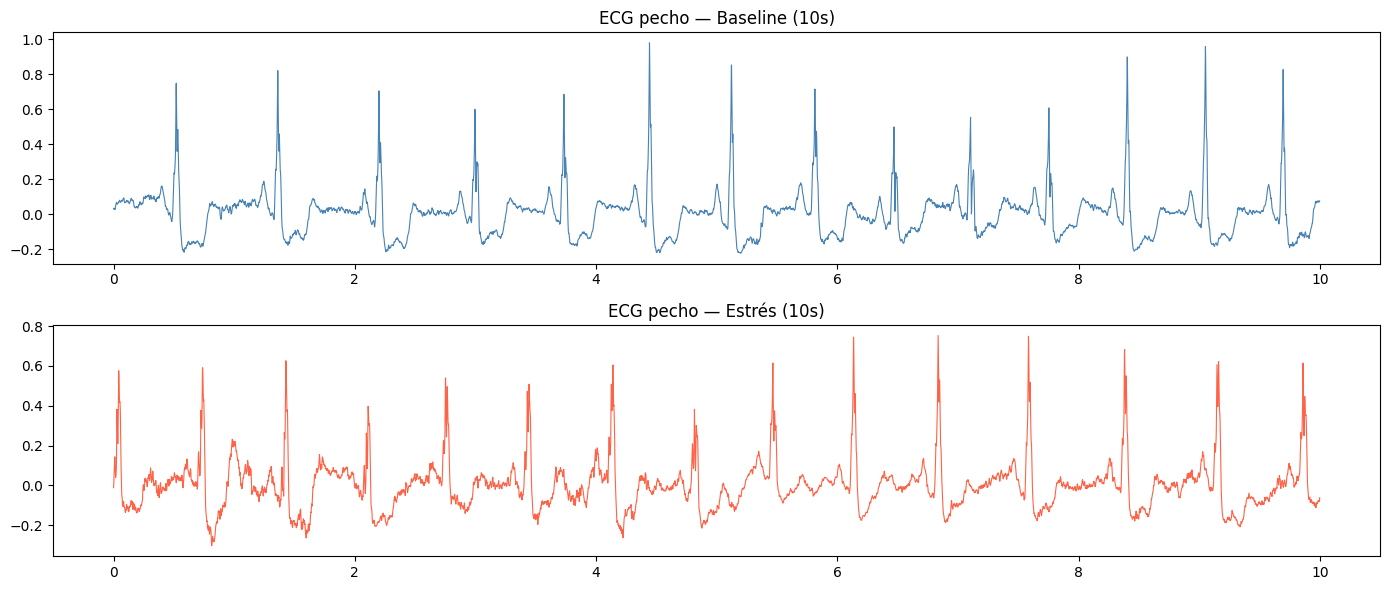

In [14]:
# Extraemos la señal ECG del pecho (chest)
# flatten() → la dejamos como vector 1D
# Frecuencia: 700 Hz → MUY alta resolución
ecg = data['signal']['chest']['ECG'].flatten()  # 700 Hz
labels_ecg = data['label'].flatten()            # ya está a 700 Hz, no necesita resampleo

print(f"ECG: {ecg.shape} muestras → {len(ecg)/700/60:.1f} minutos a 700 Hz")

# Separar por clase
baseline_ecg = ecg[labels_ecg == 1]
stress_ecg   = ecg[labels_ecg == 2]

print(f"ECG baseline: {len(baseline_ecg)/700/60:.1f} min")
print(f"ECG estrés:   {len(stress_ecg)/700/60:.1f} min")

# Creamos dos gráficos
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Eje de tiempo para 10 segundos
t = np.arange(700*10) / 700

axes[0].plot(t, baseline_ecg[:700*10], lw=0.8, color='steelblue')
axes[0].set_title("ECG pecho — Baseline (10s)")

axes[1].plot(t, stress_ecg[:700*10], lw=0.8, color='tomato')
axes[1].set_title("ECG pecho — Estrés (10s)")

plt.tight_layout()
plt.show()

---
## 11. Extracción de features desde ECG

Función de extracción usando NeuroKit2 con la señal ECG de pecho.
Misma configuración de ventanas que en el BVP (60s, overlap 50%).

In [15]:
def extraer_features_ecg(ecg_segment, fs=700):
    """
    Extrae frecuencia cardíaca media y RMSSD desde un segmento de ECG.
    
    Usa NeuroKit2 para procesamiento completo del ECG:
    - Filtrado y limpieza de la señal
    - Detección de complejos QRS (latidos)
    - Cálculo de intervalos R-R
    - Derivación de métricas de HRV

    Parámetros:
        ecg_segment: array numpy con la señal ECG cruda
        fs: frecuencia de muestreo (default: 700 Hz para RespiBAN del WESAD)
    
    Retorna:
        (hr_mean, rmssd) — NaN en caso de fallo (segmento demasiado ruidoso o corto)
    """
    try:
        # ecg_process: pipeline completo de limpieza y detección de latidos
        signals, info = nk.ecg_process(ecg_segment, sampling_rate=fs)

        # HR media en BPM
        hr_mean = signals['ECG_Rate'].mean()

        # RMSSD en milisegundos — métrica principal de HRV para estrés
        rmssd = nk.hrv_time(info, sampling_rate=fs)['HRV_RMSSD'].values[0]

        return hr_mean, rmssd

    except:
        return np.nan, np.nan

# Configuración de ventanas deslizantes
VENTANA_SEG = 60     # 60 segundos por ventana
PASO_SEG    = 30     # avance de 30s → 50% de overlap
fs_ecg      = 700    # frecuencia del ECG

resultados_ecg = []

for clase, ecg_seg in [(1, baseline_ecg), (2, stress_ecg)]:
    ventana = VENTANA_SEG * fs_ecg   # 60s × 700 Hz = 42000 muestras
    paso    = PASO_SEG * fs_ecg      # 30s × 700 Hz = 21000 muestras
    for inicio in range(0, len(ecg_seg) - ventana, paso):
        segmento = ecg_seg[inicio:inicio + ventana]
        hr, rmssd = extraer_features_ecg(segmento)
        resultados_ecg.append({'clase': clase, 'hr_mean': hr, 'rmssd': rmssd})

df_ecg = pd.DataFrame(resultados_ecg)
print(df_ecg.groupby('clase')[['hr_mean', 'rmssd']].describe().round(2))

      hr_mean                                                 rmssd         \
        count   mean   std    min    25%    50%    75%    max count   mean   
clase                                                                        
1        37.0  72.30  2.40  69.25  70.45  72.03  73.20  80.76  37.0  54.29   
2        19.0  76.87  3.22  73.43  73.99  75.99  79.55  83.00  19.0  39.65   

                                                
        std    min    25%    50%    75%    max  
clase                                           
1      6.88  43.19  49.73  52.39  59.36  71.76  
2      7.39  30.10  34.93  39.62  43.63  55.70  


---
## 12. Distribución de features — Sujeto S2

Histogramas de HR y RMSSD separados por clase para inspección visual
de la separabilidad de los datos en el sujeto de exploración.

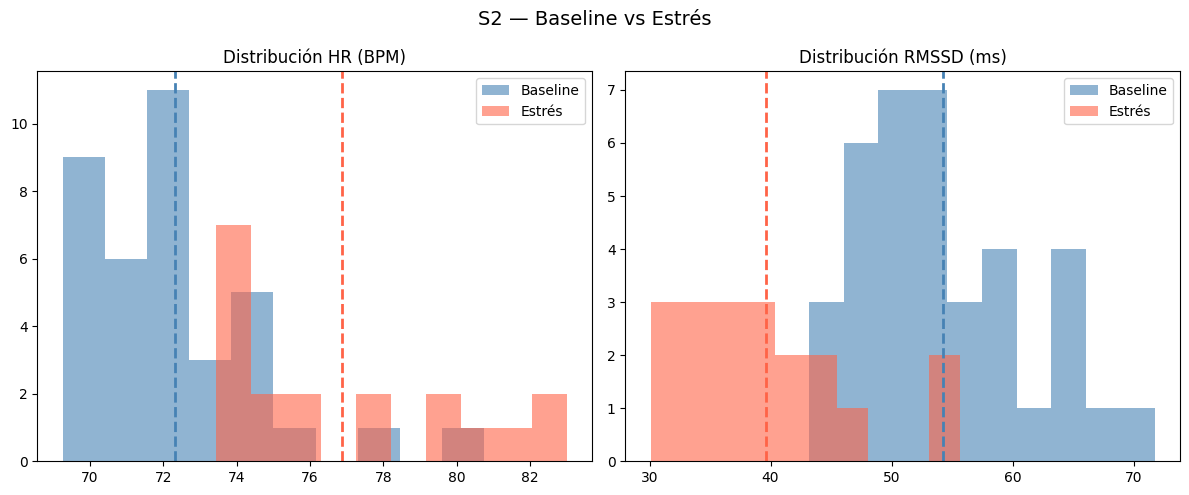

Umbral HR candidato:    > 74.6 BPM → posible estrés
Umbral RMSSD candidato: < 47.0 ms → posible estrés

Nota: estos umbrales son solo para S2. Ver sección 14 para los globales (15 sujetos).


In [16]:
# Creamos una figura con 2 gráficos (HR y RMSSD)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colores = {1: 'steelblue', 2: 'tomato'}
nombres = {1: 'Baseline', 2: 'Estrés'}

# Recorremos cada clase (baseline y estrés)
for clase in [1, 2]:

    # Filtramos el DataFrame solo para esa clase
    subset = df_ecg[df_ecg['clase'] == clase]
    # Histograma de HR (frecuencia cardíaca)
    axes[0].hist(subset['hr_mean'], alpha=0.6, bins=10,
                 color=colores[clase], label=nombres[clase])
    # Histograma de RMSSD (variabilidad)
    axes[1].hist(subset['rmssd'], alpha=0.6, bins=10,
                 color=colores[clase], label=nombres[clase])
# Promedios de HR
axes[0].axvline(df_ecg[df_ecg['clase']==1]['hr_mean'].mean(),
                color='steelblue', linestyle='--', lw=2)
axes[0].axvline(df_ecg[df_ecg['clase']==2]['hr_mean'].mean(),
                color='tomato', linestyle='--', lw=2)
axes[0].set_title("Distribución HR (BPM)")
axes[0].legend()

# Promedios de RMSSD
axes[1].axvline(df_ecg[df_ecg['clase']==1]['rmssd'].mean(),
                color='steelblue', linestyle='--', lw=2)
axes[1].axvline(df_ecg[df_ecg['clase']==2]['rmssd'].mean(),
                color='tomato', linestyle='--', lw=2)
axes[1].set_title("Distribución RMSSD (ms)")
axes[1].legend()

plt.suptitle("S2 — Baseline vs Estrés", fontsize=14)
plt.tight_layout()
plt.show()

# Umbrales candidatos
hr_umbral = (df_ecg[df_ecg['clase']==1]['hr_mean'].mean() +
             df_ecg[df_ecg['clase']==2]['hr_mean'].mean()) / 2
rmssd_umbral = (df_ecg[df_ecg['clase']==1]['rmssd'].mean() +
                df_ecg[df_ecg['clase']==2]['rmssd'].mean()) / 2

print(f"Umbral HR candidato:    > {hr_umbral:.1f} BPM → posible estrés")
print(f"Umbral RMSSD candidato: < {rmssd_umbral:.1f} ms → posible estrés")
print()
print("Nota: estos umbrales son solo para S2. Ver sección 14 para los globales (15 sujetos).")

---
## 13. Análisis del acelerómetro (filtro de movimiento)

El acelerómetro es clave para el filtro de falsos positivos de KAIROS:
si la taquicardia coincide con movimiento intenso, probablemente sea ejercicio, no crisis.

Analizamos la magnitud del vector ACC: `|a| = sqrt(ax² + ay² + az²)`

Magnitud ACC baseline — media: 63.377, std: 3.386
Magnitud ACC estrés   — media: 62.937, std: 2.737


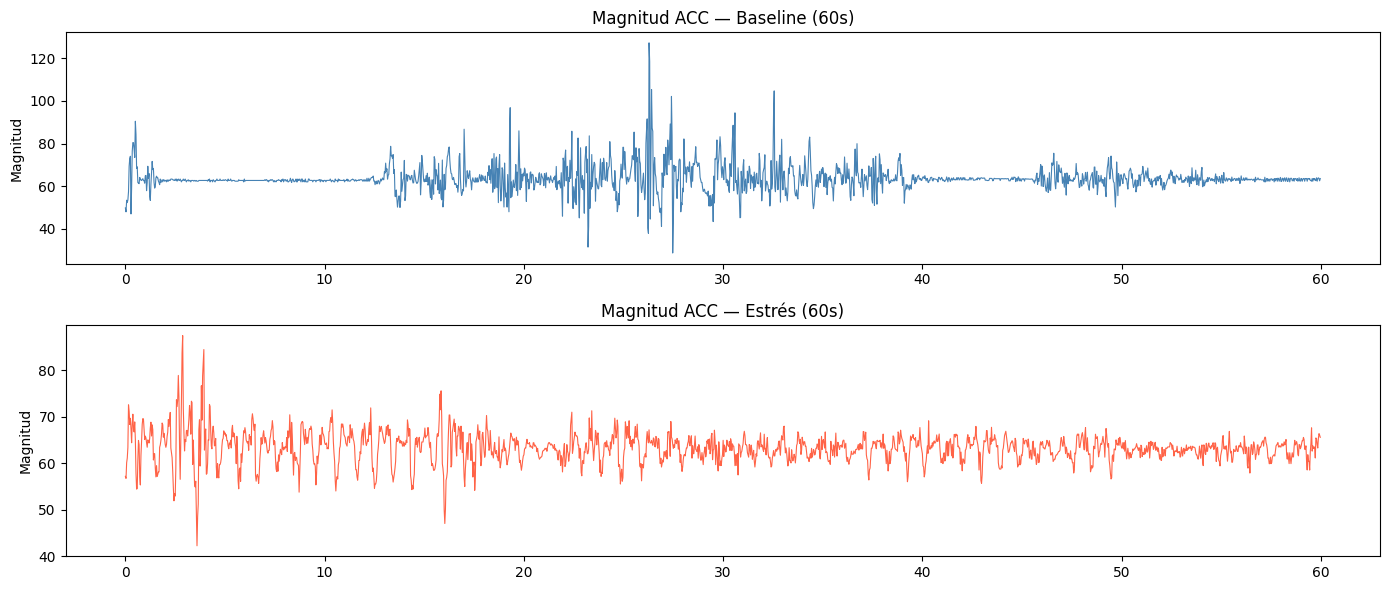

In [17]:
# ACC de muñeca a 32 Hz
acc = data['signal']['wrist']['ACC']  # shape (N, 3)

# Sincronizar labels a 32 Hz
indices_acc = np.linspace(0, len(labels)-1, len(acc))
labels_32hz = np.interp(indices_acc, np.arange(len(labels)), labels)
labels_32hz = np.round(labels_32hz).astype(int)

# Separar por clase
baseline_acc = acc[labels_32hz == 1]
stress_acc   = acc[labels_32hz == 2]

# Magnitud del vector (los 3 ejes combinados)
def magnitud(acc_segment):
    return np.sqrt(acc_segment[:,0]**2 + acc_segment[:,1]**2 + acc_segment[:,2]**2)

mag_baseline = magnitud(baseline_acc)
mag_stress   = magnitud(stress_acc)

print(f"Magnitud ACC baseline — media: {mag_baseline.mean():.3f}, std: {mag_baseline.std():.3f}")
print(f"Magnitud ACC estrés   — media: {mag_stress.mean():.3f}, std: {mag_stress.std():.3f}")

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
t_b = np.arange(len(mag_baseline)) / 32
t_s = np.arange(len(mag_stress)) / 32

axes[0].plot(t_b[:32*60], mag_baseline[:32*60], lw=0.8, color='steelblue')
axes[0].set_title("Magnitud ACC — Baseline (60s)")
axes[0].set_ylabel("Magnitud")

axes[1].plot(t_s[:32*60], mag_stress[:32*60], lw=0.8, color='tomato')
axes[1].set_title("Magnitud ACC — Estrés (60s)")
axes[1].set_ylabel("Magnitud")
    
plt.tight_layout()
plt.show()

---
## 14. Pipeline multi-sujeto: todos los sujetos WESAD

Repetimos la extracción de features para los 15 sujetos disponibles
(S2–S17, excluyendo S12 por datos incompletos).

Este paso es esencial para obtener umbrales globales estadísticamente robustos
y para poder entrenar el modelo de Random Forest con suficiente diversidad inter-sujeto.

In [18]:
import os

# Lista de sujetos del dataset WESAD
# S2 a S17, excluyendo S12 (datos incompletos)
SUJETOS = [f"S{i}" for i in range(2, 18) if i != 12]
resultados_todos = []

for sujeto in SUJETOS:
    pkl_path = f"{WESAD_PATH}/{sujeto}/{sujeto}.pkl"
    if not os.path.exists(pkl_path):
        print(f"{sujeto}: archivo no encontrado, saltando")
        continue
    
    print(f"Procesando {sujeto}...", end=' ')
    
    with open(pkl_path, 'rb') as f:
        d = pickle.load(f, encoding='latin1')
    
       # Extraemos ECG y labels
    ecg_s = d['signal']['chest']['ECG'].flatten()
    labels_s = d['label'].flatten()
    
    # Separar por clase
    baseline_s = ecg_s[labels_s == 1]
    stress_s   = ecg_s[labels_s == 2]
    
    fs_ecg = 700
    ventana = 60 * fs_ecg
    paso = 30 * fs_ecg
    
        # Recorremos baseline y estrés
    for clase, seg in [(1, baseline_s), (2, stress_s)]:
        for inicio in range(0, len(seg) - ventana, paso):
            # Extraer features del segmento
            hr, rmssd = extraer_features_ecg(seg[inicio:inicio+ventana])
            resultados_todos.append({
                'sujeto': sujeto,
                'clase': clase,
                'hr_mean': hr,
                'rmssd': rmssd
            })
    
    print("✓")

df_todos = pd.DataFrame(resultados_todos)
print("\n--- RESUMEN GLOBAL ---")
print(df_todos.groupby('clase')[['hr_mean', 'rmssd']].mean().round(2))

Procesando S2... 

/tmp/ipykernel_530767/3388187880.py:17: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='latin1')


✓
Procesando S3... 

/tmp/ipykernel_530767/3388187880.py:17: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='latin1')


✓
Procesando S4... 

...

✓
Procesando S16... 

/tmp/ipykernel_530767/3388187880.py:17: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='latin1')


✓
Procesando S17... 

/tmp/ipykernel_530767/3388187880.py:17: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='latin1')


✓

--- RESUMEN GLOBAL ---
       hr_mean  rmssd
clase                
1        72.44  51.04
2        97.94  35.75


### Resultados globales — 15 sujetos WESAD

| Feature | Baseline | Estrés | Diferencia |
|---------|----------|--------|------------|
| HR (BPM) | 72,4 | 97,9 | **+25,5 BPM** |
| RMSSD (ms) | 51,0 | 35,7 | **−15,3 ms** |

Ambas features van en la dirección correcta y con diferencias estadísticamente pronunciadas:
- HR sube durante el estrés (taquicardia) ✓
- RMSSD baja durante el estrés (reducción de variabilidad cardíaca) ✓

La diferencia de HR es mucho más pronunciada que en S2 solo (+25,5 BPM vs la diferencia
pequeña observada en la exploración inicial), lo que confirma que S2 era un caso atípico
y que el patrón es robusto a nivel poblacional.

Estos valores son la base empírica para los umbrales globales calculados en la siguiente celda.

---
## 15. Umbrales globales y curvas ROC

Calculamos umbrales estáticos basados en el punto medio entre las medias de cada clase,
y los evaluamos mediante curvas ROC con el índice de Youden para optimización.

In [19]:
# Promedios globales de HR por clase
hr_base  = df_todos[df_todos['clase']==1]['hr_mean'].mean()
hr_stress = df_todos[df_todos['clase']==2]['hr_mean'].mean()
# Promedios globales de RMSSD
rmssd_base  = df_todos[df_todos['clase']==1]['rmssd'].mean()
rmssd_stress = df_todos[df_todos['clase']==2]['rmssd'].mean()

# Umbrales globales (punto medio entre clases)
hr_umbral_global    = (hr_base + hr_stress) / 2
rmssd_umbral_global = (rmssd_base + rmssd_stress) / 2

print("=== UMBRALES KAIROS (base WESAD, 15 sujetos) ===")
print(f"HR umbral:    > {hr_umbral_global:.1f} BPM → activar pre-alerta")
print(f"RMSSD umbral: < {rmssd_umbral_global:.1f} ms → activar pre-alerta")
print()
print("=== CONDICIÓN DE DETECCIÓN ===")
print(f"Crisis probable si: HR > {hr_umbral_global:.1f} BPM  AND  RMSSD < {rmssd_umbral_global:.1f} ms")

# Guardar
import json
umbrales = {
    "hr_umbral_bpm": round(hr_umbral_global, 1),
    "rmssd_umbral_ms": round(rmssd_umbral_global, 1),
    "hr_baseline_mean": round(hr_base, 1),
    "hr_stress_mean": round(hr_stress, 1),
    "rmssd_baseline_mean": round(rmssd_base, 1),
    "rmssd_stress_mean": round(rmssd_stress, 1),
    "dataset": "WESAD",
    "n_sujetos": 15,
    "ventana_seg": 60
}

with open("umbrales_kairos.json", "w") as f:
    json.dump(umbrales, f, indent=2)

print("\nGuardado en umbrales_kairos.json ✓")

=== UMBRALES KAIROS (base WESAD, 15 sujetos) ===
HR umbral:    > 85.2 BPM → activar pre-alerta
RMSSD umbral: < 43.4 ms → activar pre-alerta

=== CONDICIÓN DE DETECCIÓN ===
Crisis probable si: HR > 85.2 BPM  AND  RMSSD < 43.4 ms

Guardado en umbrales_kairos.json ✓


HR — AUC: 0.893 | Umbral óptimo (Youden): 75.7
RMSSD — AUC: 0.666 | Umbral óptimo (Youden): 19.7


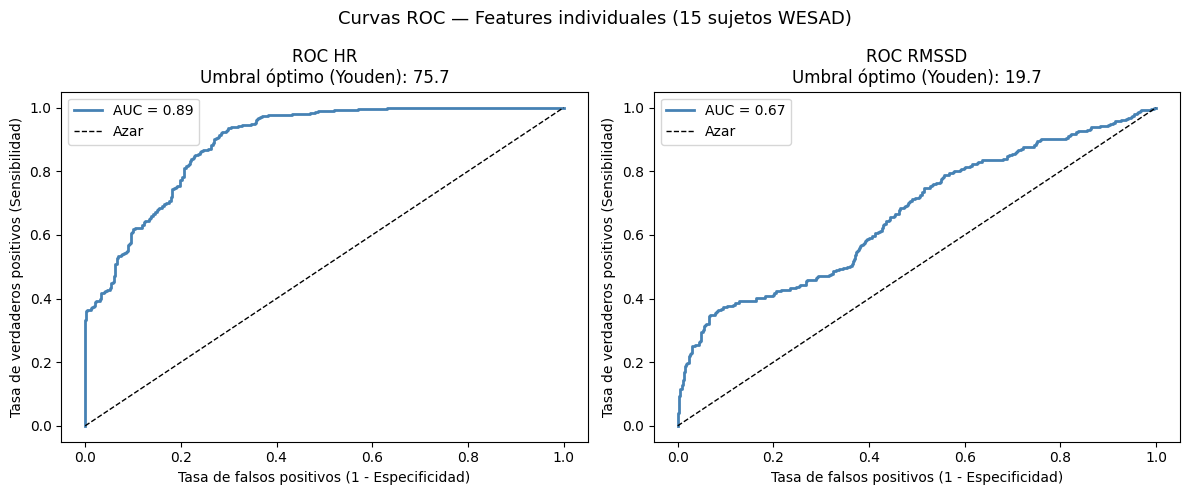

In [20]:
from sklearn.metrics import roc_curve, auc

# Variable objetivo binaria: 1 = estrés, 0 = baseline
y_true = (df_todos['clase'] == 2).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (col, label) in enumerate([('hr_mean', 'HR'), ('rmssd', 'RMSSD')]):

    # La curva ROC necesita que "más alto = más probable crisis"
    # HR: mayor HR → más estrés → el signo va bien, no se toca
    # RMSSD: mayor RMSSD → menos estrés → invertimos para que la lógica sea consistente
    scores = df_todos[col] if col == 'hr_mean' else -df_todos[col]

    # roc_curve devuelve FPR y TPR para cada umbral posible
    # Nos permite ver cómo cambia el trade-off a lo largo de todo el rango
    fpr, tpr, thresholds = roc_curve(y_true, scores)

    # AUC (Área Bajo la Curva): entre 0.5 (azar) y 1.0 (perfecto)
    # Un AUC > 0.8 indica buena capacidad discriminativa
    roc_auc = auc(fpr, tpr)

    # Índice de Youden = Sensibilidad + Especificidad - 1
    # El umbral que lo maximiza es el punto óptimo de la curva ROC:
    # equilibra minimizar FN (crisis no detectadas) y FP (falsas alarmas)
    youden = tpr - fpr
    umbral_optimo = thresholds[np.argmax(youden)]

    # Re-invertimos el umbral del RMSSD para mostrarlo en su unidad real (ms)
    # ya que al graficar usamos -RMSSD pero el umbral tiene que ser interpretable
    if col == 'rmssd':
        umbral_optimo = -umbral_optimo

    axes[i].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.2f}')
    # Línea diagonal = clasificador aleatorio (AUC = 0.5), referencia mínima
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, label='Azar')
    axes[i].set_title(f'ROC {label}\nUmbral óptimo (Youden): {umbral_optimo:.1f}')
    axes[i].set_xlabel('Tasa de falsos positivos (1 - Especificidad)')
    axes[i].set_ylabel('Tasa de verdaderos positivos (Sensibilidad)')
    axes[i].legend()

    print(f"{label} — AUC: {roc_auc:.3f} | Umbral óptimo (Youden): {umbral_optimo:.1f}")

plt.suptitle("Curvas ROC — Features individuales (15 sujetos WESAD)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 16. Validación del método Z-Score personalizado

En lugar de umbrales globales estáticos, KAIROS usa **Z-scores individuales**:
cada usuario tiene su propia línea de base personal calculada durante la calibración.

**Fórmula:**
```
z_HR    = (HR_actual - HR_media_personal) / HR_std_personal
z_RMSSD = (RMSSD_media_personal - RMSSD_actual) / RMSSD_std_personal  ← invertido
```

La inversión del RMSSD es intencional: en estrés el RMSSD baja, por lo que
un RMSSD bajo produce un Z-score positivo (alineado con la lógica de detección).

**Simulación:** usamos el 30% inicial de ventanas baseline de cada sujeto
como "calibración", y el resto como datos de evaluación.

In [21]:
from sklearn.metrics import roc_auc_score, classification_report
import json

# ─────────────────────────────────────────────────────────────────
# VALIDACIÓN DEL MÉTODO Z-SCORE SOBRE WESAD (15 sujetos)
#
# Idea central: en vez de umbrales globales estáticos (ej: HR > 85 BPM),
# cada sujeto tiene su propia línea de base personal.
# Un valor "alto" para una persona puede ser normal para otra.
#
# Simulamos el proceso de calibración de KAIROS:
# las primeras ventanas de baseline = período de calibración del usuario.
# El resto = ventanas de evaluación (donde intentamos detectar estrés).
# ─────────────────────────────────────────────────────────────────

resultados_zscore = []

for sujeto in df_todos['sujeto'].unique():
    df_sujeto = df_todos[df_todos['sujeto'] == sujeto].copy()

    # Filtramos solo las ventanas de baseline de este sujeto
    baseline_windows = df_sujeto[df_sujeto['clase'] == 1]

    # Necesitamos al menos 3 ventanas para poder separar calibración y evaluación
    if len(baseline_windows) < 3:
        continue

    # Usamos el 30% inicial del baseline como "calibración personal"
    # max(2, ...) garantiza al menos 2 ventanas aunque el 30% dé menos
    # Esto simula los primeros minutos de uso de KAIROS cuando el usuario
    # se pone el reloj y el sistema aprende su línea de base
    n_cal = max(2, int(len(baseline_windows) * 0.3))
    calibracion = baseline_windows.iloc[:n_cal]

    # Calculamos los parámetros personales de la línea de base
    # Estos son los equivalentes al algoritmo de Welford que corre en el reloj
    hr_mean    = calibracion['hr_mean'].mean()
    hr_std     = calibracion['hr_mean'].std()
    rmssd_mean = calibracion['rmssd'].mean()
    rmssd_std  = calibracion['rmssd'].std()

    # Si la std es 0, todas las ventanas tienen el mismo valor exacto
    # → no podemos calcular Z-scores (división por cero) → saltamos este sujeto
    if hr_std == 0 or rmssd_std == 0:
        continue

    # Evaluamos TODAS las ventanas restantes del sujeto (baseline + estrés)
    # Importante: incluimos el baseline restante para medir también los falsos positivos
    eval_windows = df_sujeto.iloc[n_cal:]

    for _, row in eval_windows.iterrows():
        # Z-score de HR: cuántas desviaciones estándar está la HR actual
        # por encima de la HR personal de reposo
        # Valor positivo alto → HR elevada respecto al baseline personal → posible estrés
        z_hr = (row['hr_mean'] - hr_mean) / hr_std

        # Z-score de RMSSD: invertido intencionalmente
        # En estrés el RMSSD baja → rmssd_mean - row['rmssd'] es positivo
        # Así z_rmssd positivo alto también indica estrés, igual que z_hr
        z_rmssd = (rmssd_mean - row['rmssd']) / rmssd_std

        # Score combinado: promedio simple de ambos Z-scores
        # Ambos apuntan en la misma dirección → el promedio amplifica la señal
        z_combined = (z_hr + z_rmssd) / 2

        resultados_zscore.append({
            'sujeto'    : sujeto,
            'clase'     : row['clase'],
            'z_hr'      : z_hr,
            'z_rmssd'   : z_rmssd,
            'z_combined': z_combined
        })

df_zscore = pd.DataFrame(resultados_zscore)

# Variable objetivo: 1 = estrés, 0 = baseline
y_true = (df_zscore['clase'] == 2).astype(int)

# AUC sobre los Z-scores continuos (sin aplicar umbral todavía)
# Mide qué tan bien cada feature sola separa baseline de estrés
auc_hr       = roc_auc_score(y_true, df_zscore['z_hr'])
auc_rmssd    = roc_auc_score(y_true, df_zscore['z_rmssd'])
auc_combined = roc_auc_score(y_true, df_zscore['z_combined'])

print("=== VALIDACIÓN Z-SCORE SOBRE WESAD (15 sujetos) ===")
print(f"AUC Z-HR:       {auc_hr:.3f}")
print(f"AUC Z-RMSSD:    {auc_rmssd:.3f}")
print(f"AUC Z-Combined: {auc_combined:.3f}")
print()

# Aplicamos el umbral de detección: ambos Z-scores deben superar 2.5σ
# La condición AND es más estricta que OR → reduce falsas alarmas
# Requiere evidencia simultánea de HR elevada Y RMSSD bajo
SENSITIVITY = 2.5
df_zscore['crisis_detectada'] = (
    (df_zscore['z_hr']    > SENSITIVITY) &
    (df_zscore['z_rmssd'] > SENSITIVITY)
)

print(f"=== MÉTRICAS CON UMBRAL = {SENSITIVITY}σ ===")
print("Justificación: 2.5σ equivale al percentil 98.7% bajo distribución normal.")
print("Minimiza falsas alarmas mientras mantiene detección clínicamente relevante.")
print()
print(classification_report(
    y_true,
    df_zscore['crisis_detectada'].astype(int),
    target_names=['Baseline', 'Estrés']
))

# Guardamos los parámetros de detección para referencia en la tesis
# y para reproducibilidad del experimento
params = {
    "metodo"             : "Z-Score individual",
    "sensitivity_sigmas" : SENSITIVITY,
    "justificacion"      : "Regla empirica 2.5sigma = 98.7% certeza estadistica",
    "auc_hr"             : round(auc_hr, 3),
    "auc_rmssd"          : round(auc_rmssd, 3),
    "auc_combined"       : round(auc_combined, 3),
    "dataset_validacion" : "WESAD 15 sujetos"
}
with open("kairos_detection_params.json", "w") as f:
    json.dump(params, f, indent=2)
print("Parámetros guardados en kairos_detection_params.json ✓")

=== VALIDACIÓN Z-SCORE SOBRE WESAD (15 sujetos) ===
AUC Z-HR:       0.920
AUC Z-RMSSD:    0.659
AUC Z-Combined: 0.868

=== MÉTRICAS CON UMBRAL = 2.5σ ===
Justificación: 2.5σ equivale al percentil 98.7% bajo distribución normal.
Minimiza falsas alarmas mientras mantiene detección clínicamente relevante.

              precision    recall  f1-score   support

    Baseline       0.70      0.98      0.82       401
      Estrés       0.95      0.45      0.61       311

    accuracy                           0.75       712
   macro avg       0.82      0.72      0.71       712
weighted avg       0.81      0.75      0.73       712

Parámetros guardados en kairos_detection_params.json ✓


In [22]:
# Verificación de la normalización: comprobamos que los Z-scores
# tienen el signo y la magnitud esperados antes de calcular AUC.
# En baseline deberían estar cerca de 0 (es la referencia personal).
# En estrés: z_hr positivo (HR elevada) y z_rmssd positivo (RMSSD bajo).
# Si los signos están invertidos → hay un error en la fórmula de normalización.
print("=== Z-SCORES EN WESAD POR CLASE ===")
print(df_zscore.groupby('clase')[['z_hr', 'z_rmssd']].describe().round(2))

=== Z-SCORES EN WESAD POR CLASE ===
        z_hr                                               z_rmssd        \
       count   mean    std   min   25%   50%    75%    max   count  mean   
clase                                                                      
1      401.0   0.31   1.72 -5.65 -0.91  0.07   1.46   5.73   401.0  0.19   
2      311.0  13.14  12.17 -2.48  3.86  9.73  18.46  49.39   311.0  2.09   

                                            
        std   min   25%   50%   75%    max  
clase                                       
1      1.33 -8.43 -0.45  0.31  0.87   4.79  
2      3.81 -7.25 -0.60  2.15  3.96  11.39  


### Comparación de umbrales σ

Exploramos distintos valores de sensibilidad para justificar la elección de 2.5σ
ante posibles preguntas del tribunal.

In [23]:
# Comparación de sensitivity para justificar elección de 2.5σ
for sigma in [0.5,1.0,1.15,1.20,1.5,2.0, 2.5, 3.0]:
    detected = (
        (df_zscore['z_hr'] > sigma) & 
        (df_zscore['z_rmssd'] > sigma)
    )
    tp = ((detected == True) & (y_true == 1)).sum()
    fp = ((detected == True) & (y_true == 0)).sum()
    fn = ((detected == False) & (y_true == 1)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"σ={sigma} → Precision: {precision:.2f} | Recall: {recall:.2f} | "
          f"Falsas alarmas: {fp}")

σ=0.5 → Precision: 0.67 | Recall: 0.60 | Falsas alarmas: 93
σ=1.0 → Precision: 0.80 | Recall: 0.56 | Falsas alarmas: 44
σ=1.15 → Precision: 0.82 | Recall: 0.56 | Falsas alarmas: 37
σ=1.2 → Precision: 0.84 | Recall: 0.55 | Falsas alarmas: 33
σ=1.5 → Precision: 0.89 | Recall: 0.53 | Falsas alarmas: 21
σ=2.0 → Precision: 0.95 | Recall: 0.49 | Falsas alarmas: 8
σ=2.5 → Precision: 0.95 | Recall: 0.45 | Falsas alarmas: 7
σ=3.0 → Precision: 0.97 | Recall: 0.38 | Falsas alarmas: 4


---
## 17. Random Forest — Leave-One-Subject-Out (LOGO-CV)

Entrenamos un Random Forest usando Z-scores personalizados como features.
La validación cruzada Leave-One-Subject-Out (LOGO) es el estándar para datasets
fisiológicos multi-sujeto: garantiza que el modelo nunca ve datos del sujeto
que está evaluando.

**Features:** `z_HR`, `z_RMSSD` (Z-scores personalizados por sujeto)  
**Target:** clase 2 (estrés) = 1, clase 1 (baseline) = 0

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────
# RANDOM FOREST — modelo exploratorio sobre features brutas
#
# Esta celda entrena un RF usando HR y RMSSD en sus unidades originales
# (sin normalizar por Z-score) como línea de referencia comparativa.
# El modelo final de KAIROS usa Z-scores personalizados (ver sección 17).
# ─────────────────────────────────────────────────────────────────

# Features en unidades originales (BPM y ms)
X      = df_todos[['hr_mean', 'rmssd']].values
# Target binario: 1 = estrés, 0 = baseline
y      = (df_todos['clase'] == 2).astype(int).values
# Identificador de sujeto para la validación cruzada
groups = df_todos['sujeto'].values

# Leave-One-Subject-Out (LOGO): en cada fold, un sujeto distinto es el set de test
# y el modelo se entrena con los sujetos restantes.
# Es el esquema de validación estándar para datos fisiológicos multi-sujeto porque:
# - Garantiza que el modelo nunca ve datos del sujeto que evalúa
# - Simula el escenario real: el modelo debe generalizar a usuarios nuevos
# - Evita la "data leakage" entre sujetos que ocurriría con K-Fold estándar
logo = LeaveOneGroupOut()

# n_estimators=100: 100 árboles de decisión en el ensemble
# random_state=42: semilla fija para reproducibilidad
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# cross_val_predict con LOGO devuelve las predicciones de cada sujeto
# cuando fue usado como set de testeo — nunca se predice con el modelo
# que vio los datos de ese sujeto
y_pred = cross_val_predict(clf, X, y, groups=groups, cv=logo)

print("=== RANDOM FOREST sobre features brutas (LOGO-CV) ===")
print("Nota: modelo exploratorio — compara HR/RMSSD crudos vs Z-scores")
print()
print(classification_report(y, y_pred, target_names=['Baseline', 'Estrés']))

# Feature importance: qué tan útil fue cada feature para separar las clases
# Entrenamos una vez con todos los datos para obtener este valor
# (cross_val_predict no expone el modelo entrenado internamente)
# ADVERTENCIA: este fit usa todos los sujetos — solo es válido para
# inspeccionar importancia, NO para reportar métricas de rendimiento
clf.fit(X, y)
print("=== IMPORTANCIA DE FEATURES ===")
for feat, imp in zip(['HR (BPM)', 'RMSSD (ms)'], clf.feature_importances_):
    print(f"  {feat}: {imp:.3f}")
print()
print("Interpretación: valores más altos → feature más discriminativa.")
print("Si RMSSD > HR → la variabilidad cardíaca es más útil que la frecuencia sola.")

=== RANDOM FOREST sobre features brutas (LOGO-CV) ===
Nota: modelo exploratorio — compara HR/RMSSD crudos vs Z-scores

              precision    recall  f1-score   support

    Baseline       0.85      0.84      0.85       565
      Estrés       0.72      0.73      0.73       311

    accuracy                           0.80       876
   macro avg       0.79      0.79      0.79       876
weighted avg       0.80      0.80      0.80       876

=== IMPORTANCIA DE FEATURES ===
  HR (BPM): 0.646
  RMSSD (ms): 0.354

Interpretación: valores más altos → feature más discriminativa.
Si RMSSD > HR → la variabilidad cardíaca es más útil que la frecuencia sola.


In [25]:
# Pipeline sobre Z-scores personalizados (modelo exploratorio — no es el modelo final)
# Nota: este modelo usa todos los sujetos en entrenamiento para la exploración.
# El modelo final usa split train/test por sujeto (ver sección 18).
X_z      = df_zscore[['z_hr', 'z_rmssd']].values
y_z      = (df_zscore['clase'] == 2).astype(int).values
groups_z = df_zscore['sujeto'].values

logo   = LeaveOneGroupOut()
clf_z  = RandomForestClassifier(n_estimators=100, random_state=42)
y_pred_z = cross_val_predict(clf_z, X_z, y_z, groups=groups_z, cv=logo)

print("=== RF sobre Z-scores personalizados (LOGO-CV) — modelo exploratorio ===")
print(classification_report(y_z, y_pred_z, target_names=['Baseline', 'Estrés']))

clf_z.fit(X_z, y_z)
print("Importancia de features:")
for feat, imp in zip(['Z-HR', 'Z-RMSSD'], clf_z.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

=== RF sobre Z-scores personalizados (LOGO-CV) — modelo exploratorio ===
              precision    recall  f1-score   support

    Baseline       0.83      0.89      0.86       401
      Estrés       0.84      0.77      0.80       311

    accuracy                           0.84       712
   macro avg       0.84      0.83      0.83       712
weighted avg       0.84      0.84      0.83       712

Importancia de features:
  Z-HR: 0.620
  Z-RMSSD: 0.380


---
## 18. Split train/test por sujeto y GridSearchCV

Para la evaluación final del modelo, separamos los sujetos en:
- **Train (12 sujetos):** ajuste de hiperparámetros con LOGO-CV interno
- **Test (3 sujetos):** evaluación final — nunca vistos durante el entrenamiento

Los sujetos de test se fijan con `random_state=42` para reproducibilidad.
**Nunca deben cambiarse** una vez establecidos — es la regla de integridad del experimento.

In [26]:
import numpy as np

# Fijar sujetos de testeo (elegidos al azar, nunca cambiarlos)
np.random.seed(42)
sujetos_todos = df_zscore['sujeto'].unique()

# Selección aleatoria de 3 sujetos para test (≈ 20% del total)
sujetos_test  = np.random.choice(sujetos_todos, size=3, replace=False)
sujetos_train = [s for s in sujetos_todos if s not in sujetos_test]

print(f"Sujetos de testeo:        {sujetos_test}")
print(f"Sujetos de entrenamiento: {sujetos_train}")
print(f"Total train: {len(sujetos_train)} sujetos | Total test: {len(sujetos_test)} sujetos")

# Separar datasets
mask_train = df_zscore['sujeto'].isin(sujetos_train)
mask_test  = df_zscore['sujeto'].isin(sujetos_test)

X_train    = df_zscore[mask_train][['z_hr', 'z_rmssd']].values
y_train    = (df_zscore[mask_train]['clase'] == 2).astype(int).values
groups_train = df_zscore[mask_train]['sujeto'].values

X_test  = df_zscore[mask_test][['z_hr', 'z_rmssd']].values
y_test  = (df_zscore[mask_test]['clase'] == 2).astype(int).values

print(f"\nVentanas de entrenamiento: {len(X_train)}")
print(f"Ventanas de testeo:        {len(X_test)}")

Sujetos de testeo:        ['S11' 'S14' 'S2']
Sujetos de entrenamiento: ['S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S13', 'S15', 'S16', 'S17']
Total train: 12 sujetos | Total test: 3 sujetos

Ventanas de entrenamiento: 571
Ventanas de testeo:        141


In [27]:
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier

# Grilla de hiperparámetros a explorar
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

# Optimizamos recall porque en KAIROS las crisis no detectadas (FN)
# son más perjudiciales que las falsas alarmas (FP)
clf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=LeaveOneGroupOut(),    # validación cruzada por sujeto dentro del train
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

# IMPORTANTE: entrenamos solo con sujetos de train
# Los sujetos de test no participan en absoluto en este paso
clf_grid.fit(X_train, y_train, groups=groups_train)

print(f"\nMejores parámetros: {clf_grid.best_params_}")
print(f"Mejor recall (LOGO-CV en train): {clf_grid.best_score_:.3f}")

Fitting 12 folds for each of 81 candidates, totalling 972 fits

Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Mejor recall (LOGO-CV en train): 0.806


---
## 19. Evaluación final sobre sujetos de testeo

Evaluamos el modelo entrenado sobre los 3 sujetos que **nunca participaron**
en el proceso de entrenamiento ni en la búsqueda de hiperparámetros.

Este resultado es el que se reporta en la tesis como rendimiento real del modelo.

In [28]:
from sklearn.metrics import classification_report

y_pred_test = clf_grid.best_estimator_.predict(X_test)

print("=== EVALUACIÓN FINAL SOBRE SUJETOS DE TESTEO ===")
print(f"Sujetos: {sujetos_test}")
print()
print(classification_report(y_test, y_pred_test, target_names=['Baseline', 'Estrés']))

=== EVALUACIÓN FINAL SOBRE SUJETOS DE TESTEO ===
Sujetos: ['S11' 'S14' 'S2']

              precision    recall  f1-score   support

    Baseline       0.80      0.93      0.86        80
      Estrés       0.88      0.69      0.77        61

    accuracy                           0.82       141
   macro avg       0.84      0.81      0.81       141
weighted avg       0.83      0.82      0.82       141



In [29]:
import joblib

joblib.dump(clf_grid.best_estimator_, 'kairos_model_final.pkl')

print("=== MODELO FINAL GUARDADO ===")
print(f"Archivo: kairos_model_final.pkl")
print(f"Mejores parámetros: {clf_grid.best_params_}")
print(f"Sujetos de entrenamiento: {sujetos_train}")
print(f"Sujetos de testeo: {sujetos_test}")
print(f"Recall en validación (LOGO-CV): {clf_grid.best_score_:.3f}")

=== MODELO FINAL GUARDADO ===
Archivo: kairos_model_final.pkl
Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Sujetos de entrenamiento: ['S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S13', 'S15', 'S16', 'S17']
Sujetos de testeo: ['S11' 'S14' 'S2']
Recall en validación (LOGO-CV): 0.806


---
## 20. Visualización de resultados: Matriz de Confusión y Curva ROC

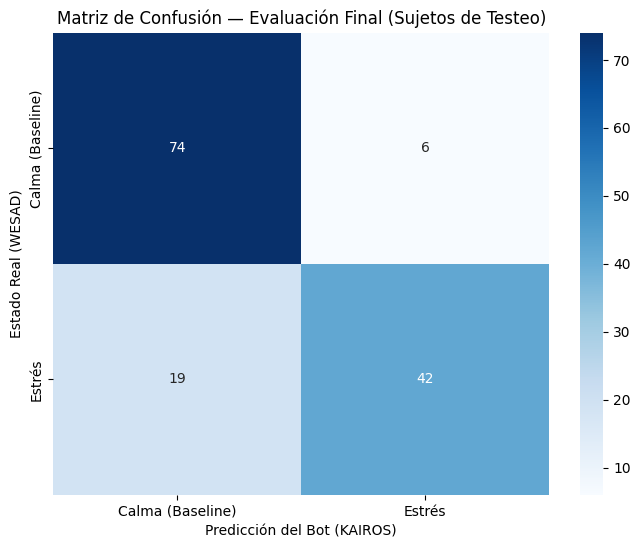

✅ Aciertos en Calma (Verdaderos Negativos): 74
✅ Aciertos en Estrés (Verdaderos Positivos): 42
❌ Falsas Alarmas (Falsos Positivos): 6
❌ Crisis no detectadas (Falsos Negativos): 19


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculamos la matriz con los resultados del set de testeo
cm = confusion_matrix(y_test, y_pred_test)

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Calma (Baseline)', 'Estrés'], 
            yticklabels=['Calma (Baseline)', 'Estrés'])

plt.xlabel('Predicción del Bot (KAIROS)')
plt.ylabel('Estado Real (WESAD)')
plt.title('Matriz de Confusión — Evaluación Final (Sujetos de Testeo)')
plt.show()

# Cálculos rápidos de la matriz
tn, fp, fn, tp = cm.ravel()
print(f"✅ Aciertos en Calma (Verdaderos Negativos): {tn}")
print(f"✅ Aciertos en Estrés (Verdaderos Positivos): {tp}")
print(f"❌ Falsas Alarmas (Falsos Positivos): {fp}")
print(f"❌ Crisis no detectadas (Falsos Negativos): {fn}")

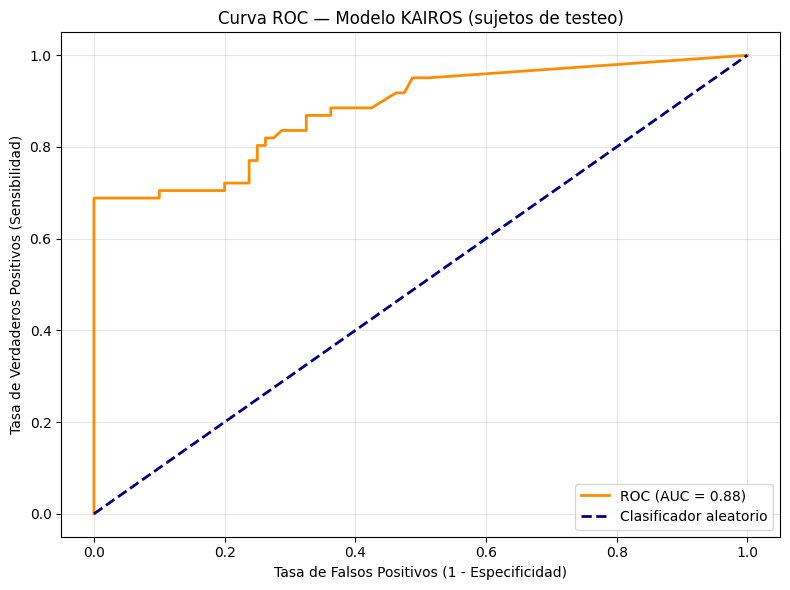

In [31]:
# Curva ROC del modelo final sobre el set de testeo
y_probs = clf_grid.best_estimator_.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC — Modelo KAIROS (sujetos de testeo)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 21. Análisis de umbrales de decisión del modelo

KAIROS usa un umbral de probabilidad (`THRESHOLD_CRISIS = 0.75`) para clasificar
una ventana como crisis. Analizamos cómo varían Recall, Precision y errores
a lo largo del rango de umbrales para justificar la elección actual.

**Trade-off clave:**
- Umbral bajo → más recalls, más falsas alarmas
- Umbral alto → menos falsas alarmas, más crisis no detectadas (FN)

Para KAIROS, un FN (crisis no detectada) es más perjudicial que un FP (falsa alarma),
por lo que priorizamos recall sobre precision.

In [32]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Análisis en umbrales clave
key_thresholds = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

print(f"{'Umbral':>8} {'Recall':>8} {'Precision':>10} {'F1':>8} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6}  Nota")
print("-" * 90)

for t in key_thresholds:
    y_pred = (y_probs >= t).astype(int)
    r  = recall_score(y_test, y_pred, zero_division=0)
    p  = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp_val = confusion_matrix(y_test, y_pred).ravel()

    nota = ''
    if t == 0.75: nota = '<-- umbral actual KAIROS (THRESHOLD_CRISIS)'
    print(f"{t:>8.2f} {r:>8.3f} {p:>10.3f} {f1:>8.3f} {tp_val:>6} {tn:>6} {fp:>6} {fn:>6}  {nota}")

print()
print("TP = crisis reales detectadas correctamente")
print("TN = baseline clasificado correctamente")
print("FP = falsas alarmas (baseline clasificado como crisis)")
print("FN = crisis no detectadas — el error más crítico para KAIROS")

  Umbral   Recall  Precision       F1     TP     TN     FP     FN  Nota
------------------------------------------------------------------------------------------
    0.45    0.689      0.875    0.771     42     74      6     19  
    0.50    0.689      0.875    0.771     42     74      6     19  
    0.55    0.689      0.894    0.778     42     75      5     19  
    0.60    0.689      0.913    0.785     42     76      4     19  
    0.65    0.689      0.913    0.785     42     76      4     19  
    0.70    0.689      0.955    0.800     42     78      2     19  
    0.75    0.689      1.000    0.816     42     80      0     19  <-- umbral actual KAIROS (THRESHOLD_CRISIS)
    0.80    0.689      1.000    0.816     42     80      0     19  

TP = crisis reales detectadas correctamente
TN = baseline clasificado correctamente
FP = falsas alarmas (baseline clasificado como crisis)
FN = crisis no detectadas — el error más crítico para KAIROS


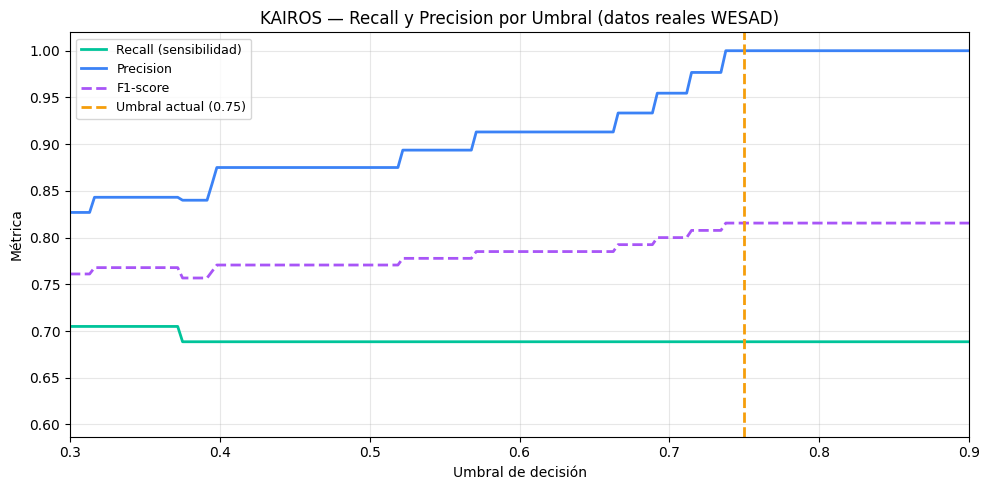

In [33]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Rango continuo de umbrales para la curva (celda 63 lo necesita)
thresholds_range = np.linspace(0.30, 0.95, 200)

recalls_r    = []
precisions_r = []
f1s_r        = []

for t in thresholds_range:
    y_pred = (y_probs >= t).astype(int)
    recalls_r.append(recall_score(y_test, y_pred, zero_division=0))
    precisions_r.append(precision_score(y_test, y_pred, zero_division=0))
    f1s_r.append(f1_score(y_test, y_pred, zero_division=0))
fig, ax = plt.subplots(figsize=(10, 5))

# Curva continua de métricas vs umbral (0.30 a 0.95)
# La tabla anterior muestra solo 8 puntos discretos — este gráfico muestra
# el comportamiento completo y revela que Recall se mantiene constante
# en 0.689 independientemente del umbral, mientras Precision sube.
ax.plot(thresholds_range, recalls_r,    color='#00C49A', lw=2, label='Recall (sensibilidad)')
ax.plot(thresholds_range, precisions_r, color='#3B82F6', lw=2, label='Precision')
ax.plot(thresholds_range, f1s_r,        color='#A855F7', lw=2, ls='--', label='F1-score')

# Línea vertical que marca el umbral elegido para KAIROS
ax.axvline(x=0.75, color='#F59E0B', ls='--', lw=2, label='Umbral actual (0.75)')

ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Métrica')
ax.set_title('KAIROS — Recall y Precision por Umbral (datos reales WESAD)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.30, 0.90)

plt.tight_layout()
plt.show()

---
## 22. Exportación del modelo a Java (m2cgen)

Para ejecutar el Random Forest en el smartwatch sin dependencias de Python,
usamos `m2cgen` (model-to-code generator) para traducir el modelo entrenado
a código Java puro.

El archivo `PredictorCrisis.java` generado es el que se integra como `Model.java`
en el módulo Wear OS de la app KAIROS.

**¿Por qué Java puro y no un runtime de ML?**
- El Pixel Watch 3 tiene recursos limitados (RAM, batería)
- No existe TensorFlow Lite para Wear OS con RF nativo
- El código generado es auto-contenido, sin dependencias
- Permite inferencia en <1ms por ventana

In [34]:
import m2cgen as m2c
import joblib

# 1. Cargamos tu modelo real con joblib (que es como se guardó en la celda 50)
model = joblib.load('kairos_model_final.pkl')

# 2. Traducimos el Random Forest entero a código Java puro
code = m2c.export_to_java(model)

# 3. Lo guardamos en un archivo
with open("PredictorCrisis.java", "w") as f:
    f.write(code)

print("¡Listo! El modelo de IA ahora es un archivo ejecutable en Java real.")

¡Listo! El modelo de IA ahora es un archivo ejecutable en Java real.
